# MADA - Resultados Unificados: Análise Comparativa

**Metodologia de Identificação de Viés Amplificado**

Este notebook apresenta a análise unificada e comparativa dos resultados obtidos nas Fases 2 (estudo empírico) e 3 (estudo sintético), confirmando ou refutando a hipótese de amplificação de viés em modelos de classificação treinados com anotações de diferentes grupos.

---

## Estrutura da Análise

**Módulo I**: Comparação de Baselines (κ_inicial)  
**Módulo II**: Comparação de Modelos Pareados  
**Módulo III**: Análise de Amplificação (Δκ)  
**Módulo IV**: Conclusões e Interpretação Acadêmica

### Conferencia do ambiente (Local x Colab)

In [2]:
import os
import sys

# 1. Detectar se o ambiente é o Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Ambiente detectado: Google Colab")
    REPO_URL = "https://github.com/alexfeitosa72/MIVA.git"
    REPO_NAME = "MIVA"

    # Clonar apenas se a pasta ainda não existir no ambiente virtual do Colab
    if not os.path.exists(REPO_NAME):
        print(f"📥 Clonando {REPO_NAME}...")
        !git clone {REPO_URL}
    
    # Entrar na pasta do repositório no Colab
    if os.getcwd().split('/')[-1] != REPO_NAME:
        os.chdir(REPO_NAME)
    
    print(f"Diretório de trabalho ajustado: {os.getcwd()}")
else:
    print(f"Ambiente detectado: Local (VS Code/Jupyter)")
    print(f"Mantendo diretório atual: {os.getcwd()}")

# 2. Listar arquivos de forma compatível (funciona em Windows, Mac, Linux e Colab)
print("\nArquivos na pasta raiz:")
print(os.listdir('.'))

Ambiente detectado: Local (VS Code/Jupyter)
Mantendo diretório atual: b:\TechLab\MIVA

Arquivos na pasta raiz:
['.claude', '.git', '.lh', '.vscode', 'data', 'fase1_tratamento_logs.ipynb', 'fase2_dados_empiricos.ipynb', 'fase3_dados_sinteticos.ipynb', 'legado', 'MADA.md', 'MADA2.md', 'resultados_MADA.ipynb', 'xtra_analise_qualitativa.ipynb', '_refs']


## 1. Setup e Importação de Dados

In [3]:
# Importações
import pandas as pd
import numpy as np
from pathlib import Path
import warnings

# Visualização
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns

# Configurações
warnings.filterwarnings('ignore')

# ============================================================================
# ESTILO ACADÊMICO NATURE (mesma paleta das Fases 2 e 3)
# ============================================================================
plt.style.use('seaborn-v0_8-whitegrid')

NATURE_BLUE = '#0C4A6E'
NATURE_BLUE_MED = '#0284C7'
NATURE_BLUE_LIGHT = '#38BDF8'
NATURE_GRAY = '#64748B'
NATURE_ACCENT = '#1E3A5F'

NATURE_PALETTE = [NATURE_BLUE, NATURE_BLUE_MED, NATURE_BLUE_LIGHT, NATURE_GRAY]

CORES_MODELOS_NATURE = {
    'SVM': '#0C4A6E',
    'NB': '#0284C7',
    'RF': '#0EA5E9',
    'LR': '#38BDF8'
}

COR_NEGATIVA = '#DC2626'
COR_NEUTRA = '#6B7280'
COR_POSITIVA = '#0284C7'

SEV_COLORS = {
    'Ausente': '#6B7280',
    'Leve': '#0284C7',
    'Moderada': '#F59E0B',
    'Severa': '#DC2626'
}

COR_EMPIRICO = '#0C4A6E'
COR_SINTETICO = '#F59E0B'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.labelweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

sns.set_palette(NATURE_PALETTE)
pd.options.display.float_format = '{:.4f}'.format

print("[OK] Bibliotecas importadas com sucesso.")
print("[OK] Estilo acadêmico Nature aplicado.")

[OK] Bibliotecas importadas com sucesso.
[OK] Estilo acadêmico Nature aplicado.


In [4]:
# Configurações globais
DATA_DIR = Path("data")
RESULTS_EMPIRICO_DIR = DATA_DIR / "resultados_empiricos"
RESULTS_SINTETICO_DIR = DATA_DIR / "resultados_sinteticos"
RESULTS_UNIFICADO_DIR = DATA_DIR / "resultados_gerais"
GRAFICOS_UNIFICADO_DIR = RESULTS_UNIFICADO_DIR / "graficos_comparativos"

RESULTS_UNIFICADO_DIR.mkdir(parents=True, exist_ok=True)
GRAFICOS_UNIFICADO_DIR.mkdir(parents=True, exist_ok=True)

print("="*80)
print("CONFIGURAÇÕES - ANÁLISE UNIFICADA MADA")
print("="*80)
print(f"Diretórios criados.")
print("="*80)

CONFIGURAÇÕES - ANÁLISE UNIFICADA MADA
Diretórios criados.


In [5]:
# Carregar dados da Fase 2 (Empírico)
print("="*80)
print("CARREGAMENTO DE DADOS")
print("="*80)

# Fase 2: Baseline
baseline_empirico = pd.read_csv(RESULTS_EMPIRICO_DIR / "metricas_consistencia_baseline.csv")
baseline_idx = baseline_empirico.set_index('metrica')['valor']
kappa_inicial_empirico = baseline_idx['Cohen_Kappa']
ic_lower_empirico = baseline_idx['Kappa_IC95_Lower']
ic_upper_empirico = baseline_idx['Kappa_IC95_Upper']

# Fase 2: Modelos pareados
metricas_empirico = pd.read_csv(RESULTS_EMPIRICO_DIR / "metricas_modelos_pareados.csv")

# Fase 2: Divergência/Amplificação
divergencia_empirico = pd.read_csv(RESULTS_EMPIRICO_DIR / "divergencia_amplificacao.csv")

print("\n[Fase 2 - Empírico]")
print(f"  Baseline: κ_inicial = {kappa_inicial_empirico:.4f} (IC95%: [{ic_lower_empirico:.4f}, {ic_upper_empirico:.4f}])")
print(f"  Modelos: {len(metricas_empirico)} classificadores avaliados")
print(f"  Amplificação: Δκ calculado para {len(divergencia_empirico)} modelos")

# Fase 3: Kappa todos classificadores
kappa_sintetico = pd.read_csv(RESULTS_SINTETICO_DIR / "kappa_todos_classificadores.csv")

# Fase 3: Delta Kappa e Severidade
delta_sintetico = pd.read_csv(RESULTS_SINTETICO_DIR / "delta_kappa_severidade.csv")

# Fase 3: Cramér's V
cramers_sintetico = pd.read_csv(RESULTS_SINTETICO_DIR / "cramers_todos_classificadores.csv")

print("\n[Fase 3 - Sintético]")
print(f"  Datasets: {len(kappa_sintetico)} datasets sintéticos (SynSA-99 a SynSA-50)")
print(f"  Modelos: 4 classificadores × {len(kappa_sintetico)} datasets")
print(f"  Amplificação: Δκ calculado para todos os pares")

print("\n" + "="*80)
print("[OK] Dados carregados com sucesso")
print("="*80)

CARREGAMENTO DE DADOS

[Fase 2 - Empírico]
  Baseline: κ_inicial = 0.7664 (IC95%: [0.7363, 0.7954])
  Modelos: 4 classificadores avaliados
  Amplificação: Δκ calculado para 4 modelos

[Fase 3 - Sintético]
  Datasets: 12 datasets sintéticos (SynSA-99 a SynSA-50)
  Modelos: 4 classificadores × 12 datasets
  Amplificação: Δκ calculado para todos os pares

[OK] Dados carregados com sucesso


## MÓDULO I: Comparação de Baselines

Comparação das concordâncias iniciais (κ_inicial) entre:
- **Fase 2**: Anotadores humanos (masculino vs feminino) em dados reais
- **Fase 3**: Anotadores sintéticos (masculino vs feminino) em diferentes níveis de concordância controlada

In [6]:
# ============================================================================
# TABELA I.1 — Baseline Empírico vs Sintéticos
# ============================================================================

print("="*80)
print("MÓDULO I: COMPARAÇÃO DE BASELINES")
print("="*80)

# Extrair baselines sintéticos
baselines_sintetico = kappa_sintetico[['Dataset', 'Originais κ', 'Faixa L&K']].copy()
baselines_sintetico.columns = ['Dataset', 'κ_inicial', 'Faixa L&K']

# Criar linha para baseline empírico
baseline_empirico_row = pd.DataFrame({
    'Dataset': ['Empírico (MQD-1222)'],
    'κ_inicial': [kappa_inicial_empirico],
    'Faixa L&K': ['Substantial']
})

# Consolidar
baselines_todos = pd.concat([baseline_empirico_row, baselines_sintetico], ignore_index=True)

print("\nTabela I.1 — Concordância Inicial (κ_inicial) por Dataset")
print("-"*80)
print(baselines_todos.to_string(index=False, float_format='{:.4f}'.format))

# Salvar
baselines_todos.to_csv(RESULTS_UNIFICADO_DIR / 'baselines_comparados.csv', index=False)
print(f"\n[OK] Tabela salva: baselines_comparados.csv")

MÓDULO I: COMPARAÇÃO DE BASELINES

Tabela I.1 — Concordância Inicial (κ_inicial) por Dataset
--------------------------------------------------------------------------------
            Dataset  κ_inicial      Faixa L&K
Empírico (MQD-1222)     0.7664    Substantial
           SynSA-99     0.9850 Almost Perfect
           SynSA-97     0.9550 Almost Perfect
           SynSA-95     0.9249 Almost Perfect
           SynSA-90     0.8498 Almost Perfect
           SynSA-85     0.7748    Substantial
           SynSA-80     0.6997    Substantial
           SynSA-75     0.6246    Substantial
           SynSA-70     0.5495       Moderate
           SynSA-65     0.4745       Moderate
           SynSA-60     0.3994           Fair
           SynSA-55     0.3243           Fair
           SynSA-50     0.2507           Fair

[OK] Tabela salva: baselines_comparados.csv


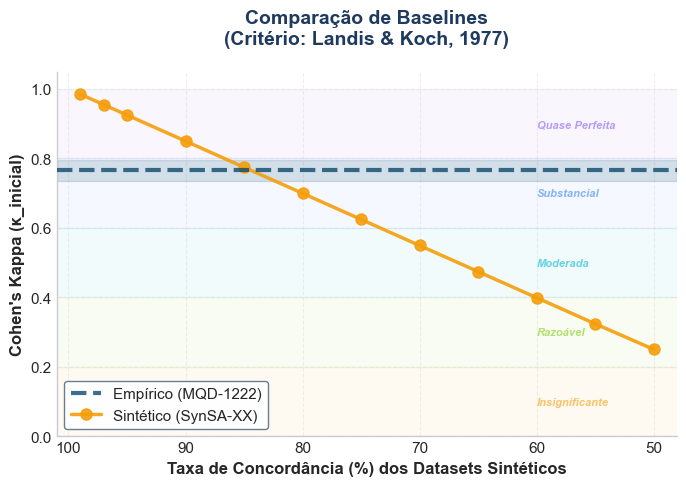


[OK] Gráfico I.1 salvo: comparacao_baselines.png


In [7]:
# ============================================================================
# GRÁFICO I.1 — Baseline: Empírico vs Sintéticos
# ============================================================================

fig, ax = plt.subplots(figsize=(7, 5))

# Baseline empírico (linha horizontal de referência)
ax.axhline(y=kappa_inicial_empirico, color=COR_EMPIRICO, linestyle='--', 
           linewidth=3, alpha=0.8, label='Empírico (MQD-1222)', zorder=5)

# IC95% do empírico (área sombreada)
ax.axhspan(ic_lower_empirico, ic_upper_empirico, alpha=0.15, color=COR_EMPIRICO, zorder=1)

# Baselines sintéticos (curva)
x_sintetico = [int(ds.split('-')[1]) for ds in baselines_sintetico['Dataset']]
y_sintetico = baselines_sintetico['κ_inicial'].values

ax.plot(x_sintetico, y_sintetico, marker='o', linewidth=2.5, markersize=8,
        color=COR_SINTETICO, label='Sintético (SynSA-XX)', alpha=0.9, zorder=3)

# Faixas de Landis & Koch (1977) — valores originais do artigo
# Poor: < 0.00 | Slight: 0.00–0.20 | Fair: 0.21–0.40
# Moderate: 0.41–0.60 | Substantial: 0.61–0.80 | Almost Perfect: 0.81–1.00
faixas = [
    ('Insignificante', 0.0, 0.20, '#F59E0B'),
    ('Razoável', 0.20, 0.40, '#84CC16'),
    ('Moderada', 0.40, 0.60, '#06B6D4'),
    ('Substancial', 0.60, 0.80, '#3B82F6'),
    ('Quase Perfeita', 0.80, 1.00, '#8B5CF6')
]

for nome, y_low, y_high, cor in faixas:
    ax.axhspan(y_low, y_high, alpha=0.05, color=cor, zorder=0)
    y_mid = (y_low + y_high) / 2
    ax.text(60, y_mid, nome, fontsize=8, alpha=0.6, style='italic',
            verticalalignment='center', horizontalalignment='left',
            color=cor, fontweight='bold')

ax.set_xlabel('Taxa de Concordância (%) dos Datasets Sintéticos', 
              fontsize=12, fontweight='bold')
ax.set_ylabel("Cohen's Kappa (κ_inicial)", fontsize=12, fontweight='bold')
ax.set_title("Comparação de Baselines\n"
            "(Critério: Landis & Koch, 1977)",
             fontsize=14, fontweight='bold', color=NATURE_ACCENT, pad=20)

ax.legend(loc='lower left', fontsize=11, frameon=True, 
          facecolor='white', edgecolor=NATURE_GRAY, framealpha=0.95)

ax.set_xlim(101, 48)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(GRAFICOS_UNIFICADO_DIR / 'comparacao_baselines.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n[OK] Gráfico I.1 salvo: comparacao_baselines.png")

## MÓDULO II: Comparação de Modelos Pareados

Comparação das concordâncias entre modelos (κ_modelos) nas duas fases:
- **Fase 2**: Concordância entre predições de modelos M/F treinados com dados empíricos
- **Fase 3**: Concordância entre predições de modelos M/F em datasets sintéticos

In [8]:
# ============================================================================
# TABELA II.1 — κ_modelos: Empírico vs Sintéticos (por classificador)
# ============================================================================

print("\n" + "="*80)
print("MÓDULO II: COMPARAÇÃO DE MODELOS PAREADOS")
print("="*80)

# Extrair κ_modelos empírico
kappa_modelos_empirico = metricas_empirico[['modelo', 'kappa_mean']].copy()
kappa_modelos_empirico.columns = ['Modelo', 'κ_modelos_empirico']

# Extrair κ_modelos sintético (média de todos os datasets)
modelos = ['SVM', 'NB', 'RF', 'LR']
kappa_modelos_sintetico_df = pd.DataFrame([
    {'Modelo': m, 'κ_modelos_sintetico_media': kappa_sintetico[f'{m} κ'].mean()}
    for m in modelos
])

# Merge
tabela_modelos = kappa_modelos_empirico.merge(kappa_modelos_sintetico_df, on='Modelo')

print("\nTabela II.1 — Concordância intermodelos (κ_modelos) por Classificador")
print("-"*80)
print(tabela_modelos.to_string(index=False, float_format='{:.4f}'.format))

# Salvar
tabela_modelos.to_csv(RESULTS_UNIFICADO_DIR / 'kappa_modelos_comparado.csv', index=False)
print(f"\n[OK] Tabela salva: kappa_modelos_comparado.csv")


MÓDULO II: COMPARAÇÃO DE MODELOS PAREADOS

Tabela II.1 — Concordância intermodelos (κ_modelos) por Classificador
--------------------------------------------------------------------------------
Modelo  κ_modelos_empirico  κ_modelos_sintetico_media
   SVM              0.4944                     0.4571
    NB              0.4582                     0.4619
    RF              0.4863                     0.1843
    LR              0.5120                     0.4727

[OK] Tabela salva: kappa_modelos_comparado.csv


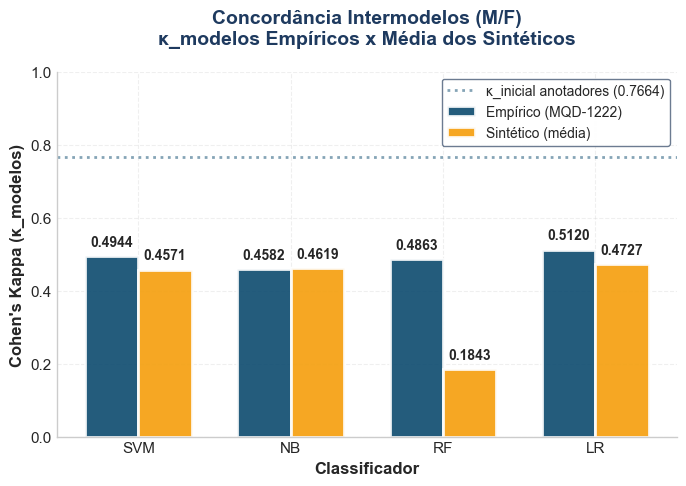


[OK] Gráfico II.1 salvo: kappa_modelos_comparado.png


In [9]:
# ============================================================================
# GRÁFICO II.1 — κ_modelos: Empírico vs Sintéticos (barras agrupadas)
# ============================================================================

fig, ax = plt.subplots(figsize=(7, 5))

x = np.arange(len(modelos))
width = 0.35

bars1 = ax.bar(x - width/2, tabela_modelos['κ_modelos_empirico'], width,
               label='Empírico (MQD-1222)', color=COR_EMPIRICO, alpha=0.9,
               edgecolor='white', linewidth=2)

bars2 = ax.bar(x + width/2, tabela_modelos['κ_modelos_sintetico_media'], width,
               label='Sintético (média)', color=COR_SINTETICO, alpha=0.9,
               edgecolor='white', linewidth=2)

# Linha de κ_inicial empírico como referência
ax.axhline(y=kappa_inicial_empirico, color=COR_EMPIRICO, linestyle=':', 
           linewidth=2, alpha=0.5, label=f'κ_inicial anotadores ({kappa_inicial_empirico:.4f})')

# Anotações
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.4f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

ax.set_xlabel('Classificador', fontsize=12, fontweight='bold')
ax.set_ylabel("Cohen's Kappa (κ_modelos)", fontsize=12, fontweight='bold')
ax.set_title("Concordância Intermodelos (M/F)\n"
             "κ_modelos Empíricos x Média dos Sintéticos",
             fontsize=14, fontweight='bold', color=NATURE_ACCENT, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.legend(loc='upper right', fontsize=10, frameon=True,
          facecolor='white', edgecolor=NATURE_GRAY, framealpha=0.95)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(GRAFICOS_UNIFICADO_DIR / 'kappa_modelos_comparado.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n[OK] Gráfico II.1 salvo: kappa_modelos_comparado.png")

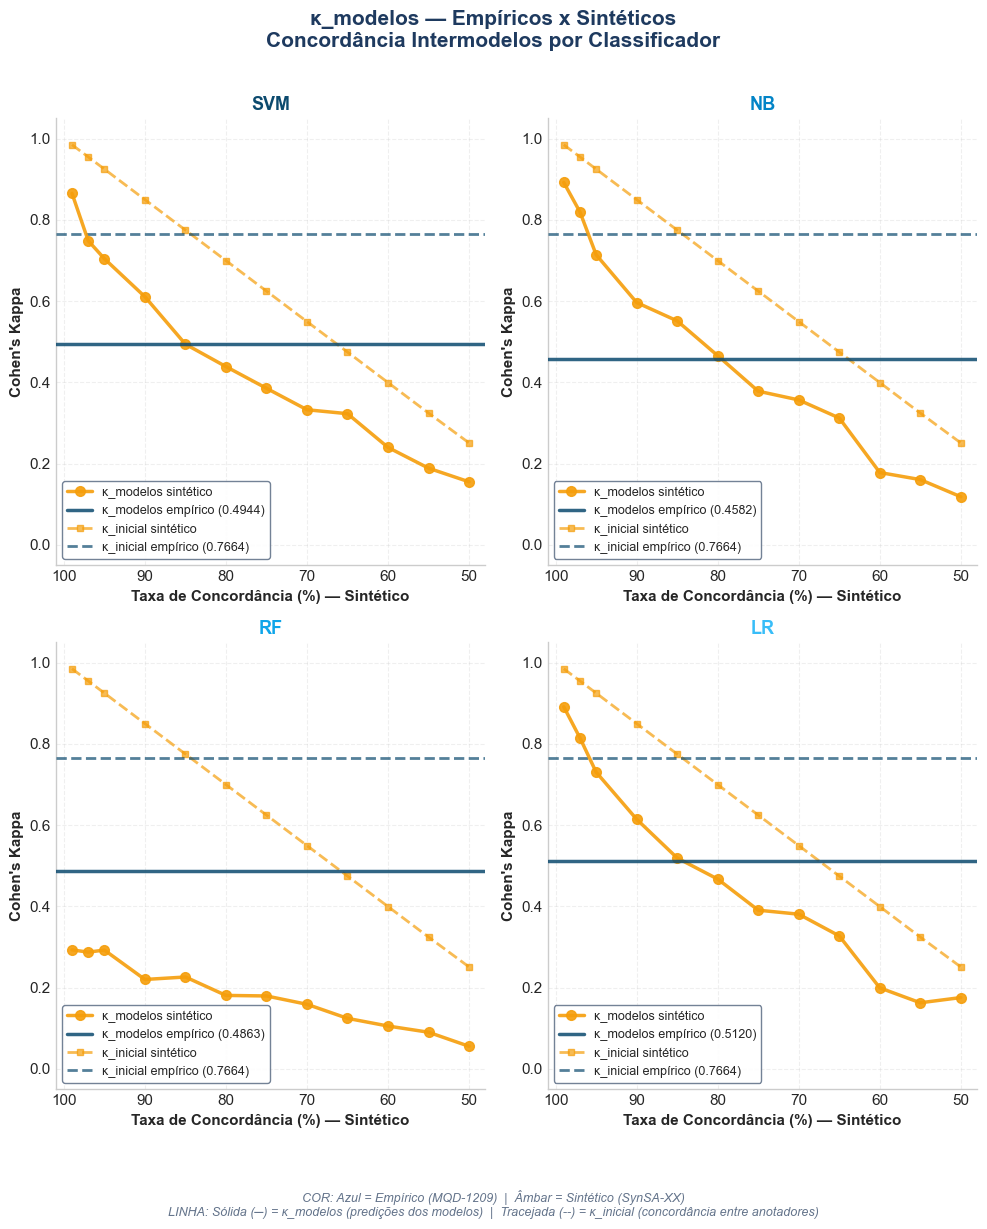


[OK] Gráfico II.2 salvo: kappa_modelos_sobrepostos.png


In [10]:

# ============================================================================
# GRÁFICO II.2 — κ_modelos: Empírico sobreposto aos Sintéticos (curvas)
# ============================================================================
# Convenção visual:
#   COR   → fase: Azul escuro = Empírico | Âmbar = Sintético
#   LINHA → tipo: Sólida = κ_modelos (predições) | Tracejada = κ_inicial (anotadores)

fig, axes = plt.subplots(2, 2, figsize=(10, 12))
axes = axes.flatten()

x_sintetico = [int(ds.split('-')[1]) for ds in kappa_sintetico['Dataset']]
y_kin_sin = baselines_sintetico['κ_inicial'].values

for idx, modelo in enumerate(modelos):
    ax = axes[idx]

    # --- κ_modelos sintético: âmbar, sólida, círculos ---
    y_kmod_sin = kappa_sintetico[f'{modelo} κ'].values
    ax.plot(x_sintetico, y_kmod_sin,
            color=COR_SINTETICO, linestyle='-', linewidth=2.5,
            marker='o', markersize=7, alpha=0.9,
            label='κ_modelos sintético', zorder=4)

    # --- κ_modelos empírico: azul, sólida, linha horizontal ---
    kappa_modelo_empirico = metricas_empirico[
        metricas_empirico['modelo'] == modelo]['kappa_mean'].values[0]
    ax.axhline(y=kappa_modelo_empirico,
               color=COR_EMPIRICO, linestyle='-', linewidth=2.5, alpha=0.85,
               label=f'κ_modelos empírico ({kappa_modelo_empirico:.4f})', zorder=5)

    # --- κ_inicial sintético: âmbar, tracejada, quadrados ---
    ax.plot(x_sintetico, y_kin_sin,
            color=COR_SINTETICO, linestyle='--', linewidth=2,
            marker='s', markersize=5, alpha=0.7,
            label='κ_inicial sintético', zorder=2)

    # --- κ_inicial empírico: azul, tracejada, linha horizontal ---
    ax.axhline(y=kappa_inicial_empirico,
               color=COR_EMPIRICO, linestyle='--', linewidth=2, alpha=0.7,
               label=f'κ_inicial empírico ({kappa_inicial_empirico:.4f})', zorder=3)

    ax.set_xlabel('Taxa de Concordância (%) — Sintético', fontsize=11, fontweight='bold')
    ax.set_ylabel("Cohen's Kappa", fontsize=11, fontweight='bold')
    ax.set_title(f'{modelo}', fontsize=13, fontweight='bold',
                 color=CORES_MODELOS_NATURE[modelo])
    ax.legend(loc='lower left', fontsize=9, frameon=True,
              facecolor='white', edgecolor=NATURE_GRAY, framealpha=0.9)
    ax.set_xlim(101, 48)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3, linestyle='--')

# Nota de rodapé com a convenção dupla
fig.text(0.5, -0.01,
         "COR: Azul = Empírico (MQD-1209)  |  Âmbar = Sintético (SynSA-XX)\n"
         "LINHA: Sólida (─) = κ_modelos (predições dos modelos)  |  "
         "Tracejada (--) = κ_inicial (concordância entre anotadores)",
         ha='center', fontsize=9, style='italic', color=NATURE_GRAY)

plt.suptitle("κ_modelos — Empíricos x Sintéticos\n"
             "Concordância Intermodelos por Classificador",
             fontsize=15, fontweight='bold', color=NATURE_ACCENT, y=0.995)
plt.tight_layout(rect=[0, 0.05, 1, 0.985])
plt.savefig(GRAFICOS_UNIFICADO_DIR / 'kappa_modelos_sobrepostos.png',
            dpi=300, bbox_inches='tight')
plt.show()

print("\n[OK] Gráfico II.2 salvo: kappa_modelos_sobrepostos.png")

## MÓDULO III: Análise de Amplificação (Δκ)

**Núcleo da metodologia MADA**: Comparação do Delta Kappa (Δκ = κ_inicial - κ_modelos) entre fases.

**Critério de Severidade**: Baseado em **Landis & Koch (1977)**, pela queda de faixas de concordância.

In [11]:
# ============================================================================
# TABELA III.1 — Delta Kappa e Severidade: Empírico vs Sintéticos
# ============================================================================

print("\n" + "="*80)
print("MÓDULO III: ANÁLISE DE AMPLIFICAÇÃO (Δκ)")
print("="*80)

# Extrair Δκ empírico
delta_empirico_tbl = divergencia_empirico[['modelo', 'delta_kappa', 'severidade', 'faixas_perdidas']].copy()
delta_empirico_tbl.columns = ['Modelo', 'Δκ_empirico', 'Severidade_empirico', 'Faixas_empirico']

# Extrair Δκ sintético (média de todos os datasets)
delta_sintetico_media = []
for modelo in modelos:
    col_dk = f'{modelo} Δκ'
    col_sev = f'{modelo} Sev'
    col_fx = f'{modelo} Faixas'

    sev_mode = delta_sintetico[col_sev].mode()
    delta_sintetico_media.append({
        'Modelo': modelo,
        'Δκ_sintetico_media': delta_sintetico[col_dk].mean(),
        'Severidade_sintetico_modal': sev_mode.iloc[0] if len(sev_mode) > 0 else 'Ausente',
        'Faixas_sintetico_media': delta_sintetico[col_fx].mean()
    })

delta_sintetico_tbl = pd.DataFrame(delta_sintetico_media)

# Merge
tabela_delta = delta_empirico_tbl.merge(delta_sintetico_tbl, on='Modelo')

print("\nTabela III.1 — Delta Kappa (Δκ) e Severidade: Empírico vs Sintético")
print("-"*80)
print(tabela_delta.to_string(index=False))

# Salvar
tabela_delta.to_csv(RESULTS_UNIFICADO_DIR / 'delta_kappa_comparado.csv', index=False)
print(f"\n[OK] Tabela salva: delta_kappa_comparado.csv")


MÓDULO III: ANÁLISE DE AMPLIFICAÇÃO (Δκ)

Tabela III.1 — Delta Kappa (Δκ) e Severidade: Empírico vs Sintético
--------------------------------------------------------------------------------
Modelo  Δκ_empirico Severidade_empirico  Faixas_empirico  Δκ_sintetico_media Severidade_sintetico_modal  Faixas_sintetico_media
   SVM       0.2720                Leve                1              0.1939                       Leve                  0.9167
    NB       0.3082                Leve                1              0.1892                       Leve                  1.0000
    RF       0.2801                Leve                1              0.4667                     Severa                  2.2500
    LR       0.2544                Leve                1              0.1784                       Leve                  0.9167

[OK] Tabela salva: delta_kappa_comparado.csv


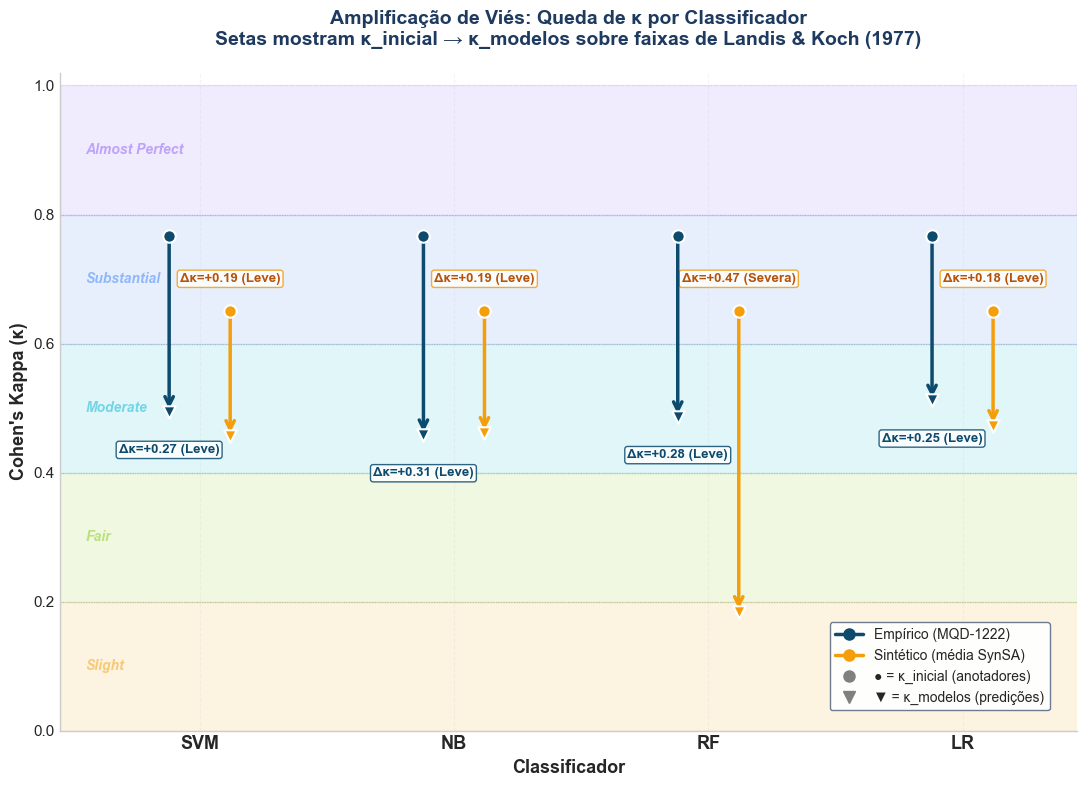


[OK] Gráfico III.1 salvo: delta_kappa_comparado.png


In [12]:
# ============================================================================
# GRÁFICO III.1 — Amplificação de Viés: Dumbbell Chart com Faixas L&K
# ============================================================================
# Cada seta mostra a queda de κ_inicial → κ_modelos.
# As faixas de Landis & Koch (1977) como fundo tornam a severidade auto-evidente:
# a quantidade de faixas coloridas que a seta atravessa = severidade.

fig, ax = plt.subplots(figsize=(11, 8))

# --- Faixas de Landis & Koch como fundo ---
faixas_lk = [
    ('Slight',          0.00, 0.20, '#F59E0B'),
    ('Fair',            0.20, 0.40, '#84CC16'),
    ('Moderate',        0.40, 0.60, '#06B6D4'),
    ('Substantial',     0.60, 0.80, '#3B82F6'),
    ('Almost Perfect',  0.80, 1.00, '#8B5CF6'),
]

for nome, y_low, y_high, cor in faixas_lk:
    ax.axhspan(y_low, y_high, alpha=0.12, color=cor, zorder=0)
    y_mid = (y_low + y_high) / 2
    ax.text(-0.45, y_mid, nome, fontsize=10, alpha=0.5,
            style='italic', va='center', ha='left', color=cor, fontweight='bold')

for _, y_low, y_high, _ in faixas_lk:
    ax.axhline(y=y_low, color='gray', linestyle=':', linewidth=0.7, alpha=0.4, zorder=1)


def desenhar_seta(ax, x, k_ini, k_mod, dk, sev, cor, label_va, label_offset):
    """Desenha seta κ_inicial → κ_modelos com rótulo de Δκ."""
    ax.annotate('', xy=(x, k_mod), xytext=(x, k_ini),
                arrowprops=dict(arrowstyle='->', color=cor, lw=2.5, mutation_scale=15),
                zorder=5)
    ax.scatter(x, k_ini, color=cor, s=80, zorder=6,
               edgecolors='white', linewidths=1.5, marker='o')
    ax.scatter(x, k_mod, color=cor, s=80, zorder=6,
               edgecolors='white', linewidths=1.5, marker='v')

    cor_texto = '#B45309' if cor == COR_SINTETICO else cor
    ax.text(x, label_offset,
            f'Δκ={dk:+.2f} ({sev})',
            fontsize=9.5, ha='center', va=label_va, color=cor_texto,
            fontweight='bold', bbox=dict(boxstyle='round,pad=0.2',
            facecolor='white', edgecolor=cor, alpha=0.85))


# --- Dados ---
x_positions = np.arange(len(modelos))
offset = 0.12

for idx, modelo in enumerate(modelos):
    row = tabela_delta[tabela_delta['Modelo'] == modelo].iloc[0]

    # Empírico
    k_ini_emp = kappa_inicial_empirico
    k_mod_emp = metricas_empirico[metricas_empirico['modelo'] == modelo]['kappa_mean'].values[0]
    desenhar_seta(ax, idx - offset, k_ini_emp, k_mod_emp,
                  row['Δκ_empirico'], row['Severidade_empirico'],
                  COR_EMPIRICO, 'top', k_mod_emp - 0.05)

    # Sintético (média)
    k_ini_sin = baselines_sintetico['κ_inicial'].mean()
    k_mod_sin = kappa_sintetico[f'{modelo} κ'].mean()
    desenhar_seta(ax, idx + offset, k_ini_sin, k_mod_sin,
                  row['Δκ_sintetico_media'], row['Severidade_sintetico_modal'],
                  COR_SINTETICO, 'bottom', k_ini_sin + 0.04)

# --- Legenda manual ---
legend_elements = [
    Line2D([0], [0], color=COR_EMPIRICO, lw=2.5, marker='o', markersize=8,
           label='Empírico (MQD-1222)', markerfacecolor=COR_EMPIRICO),
    Line2D([0], [0], color=COR_SINTETICO, lw=2.5, marker='o', markersize=8,
           label='Sintético (média SynSA)', markerfacecolor=COR_SINTETICO),
    Line2D([0], [0], color='gray', lw=0, marker='o', markersize=8,
           label='● = κ_inicial (anotadores)', markerfacecolor='gray'),
    Line2D([0], [0], color='gray', lw=0, marker='v', markersize=8,
           label='▼ = κ_modelos (predições)', markerfacecolor='gray'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10, frameon=True,
          facecolor='white', edgecolor=NATURE_GRAY, framealpha=0.95,
          bbox_to_anchor=(0.98, 0.02))

# --- Eixos ---
ax.set_xticks(x_positions)
ax.set_xticklabels(modelos, fontsize=13, fontweight='bold')
ax.set_xlabel('Classificador', fontsize=13, fontweight='bold')
ax.set_ylabel("Cohen's Kappa (κ)", fontsize=13, fontweight='bold')
ax.set_title("Amplificação de Viés: Queda de κ por Classificador\n"
             "Setas mostram κ_inicial → κ_modelos sobre faixas de Landis & Koch (1977)",
             fontsize=14, fontweight='bold', color=NATURE_ACCENT, pad=20)

ax.set_xlim(-0.55, len(modelos) - 0.55)
ax.set_ylim(0, 1.02)
ax.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.savefig(GRAFICOS_UNIFICADO_DIR / 'delta_kappa_comparado.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n[OK] Gráfico III.1 salvo: delta_kappa_comparado.png")

In [ ]:
# ============================================================================
# GRÁFICO III.2 — Delta Kappa: Empírico sobreposto aos Sintéticos (curvas)
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for idx, modelo in enumerate(modelos):
    ax = axes[idx]

    # Curva sintética (Δκ por dataset)
    col_dk = f\'{modelo} Δκ\'
    x_sintetico = [int(ds.split(\'-\')[1]) for ds in delta_sintetico[\'Dataset\']]
    y_delta_sintetico = delta_sintetico[col_dk].values

    ax.plot(x_sintetico, y_delta_sintetico, marker=\'o\', linewidth=2.5, markersize=7,
            color=COR_SINTETICO, label=\'Sintético (Δκ)\', alpha=0.9, zorder=3)

    # Linha de Δκ empírico
    delta_empirico_val = divergencia_empirico[divergencia_empirico[\'modelo\'] == modelo][\'delta_kappa\'].values[0]
    ax.axhline(y=delta_empirico_val, color=COR_EMPIRICO, linestyle=\'--\',
               linewidth=3, alpha=0.8, label=f\'Empírico: {delta_empirico_val:+.4f}\', zorder=5)

    # Linha de referência (Δκ = 0)
    ax.axhline(y=0, color=\'black\', linestyle=\'-\', linewidth=1.5, alpha=0.5, zorder=1)

    # Área de amplificação (Δκ > 0)
    ax.axhspan(0, 0.5, alpha=0.05, color=\'red\', zorder=0)
    ax.text(51, 0.25, \'Amplificação\', fontsize=9, alpha=0.4, style=\'italic\',
            color=\'red\', fontweight=\'bold\')

    ax.set_xlabel(\'Concordância Nominal (%) - Sintético\', fontsize=11, fontweight=\'bold\')
    ax.set_ylabel(\'Δκ (κ_inicial - κ_modelos)\', fontsize=11, fontweight=\'bold\')
    ax.set_title(f\'{modelo}\', fontsize=13, fontweight=\'bold\', color=CORES_MODELOS_NATURE[modelo])
    ax.legend(loc=\'best\', fontsize=9, frameon=True, facecolor=\'white\',
              edgecolor=NATURE_GRAY, framealpha=0.9)
    ax.set_xlim(101, 48)
    ax.grid(True, alpha=0.3, linestyle=\'--\')

plt.suptitle("Δκ - Empírico x Sintéticos\n"
             "Amplificação de Viés por Classificador",
             fontsize=15, fontweight=\'bold\', color=NATURE_ACCENT, y=0.995)

# Nota interpretativa por classificador (referência para a legenda da dissertação)
# SVM/LR: empírico contido na curva (~80-85%); NB: empírico acima do teto sintético; RF: empírico na região de baixa concordância
fig.text(0.5, -0.02,
         "Linha tracejada azul: Δκ empírico (MQD-1222). Curva âmbar: Δκ sintético (SynSA-50 a SynSA-99). "
         "Fundo vermelho: região de amplificação (Δκ > 0).\n"
         "SVM e LR: valor empírico contido na curva (~80–85% de concordância). "
         "NB: valor empírico (0,31) supera o teto da curva sintética (0,25). "
         "RF: valor empírico (0,28) alinha-se à região de baixa concordância (~55–60%).",
         ha=\'center\', fontsize=8.5, style=\'italic\', color=NATURE_GRAY)

plt.tight_layout(rect=[0, 0.06, 1, 0.985])
plt.savefig(GRAFICOS_UNIFICADO_DIR / \'delta_kappa_sobrepostos.png\', dpi=300, bbox_inches=\'tight\')
plt.show()

print("\n[OK] Gráfico III.2 salvo: delta_kappa_sobrepostos.png")

## MÓDULO IV: Conclusões e Interpretação Acadêmica

Síntese dos resultados unificados e validação da hipótese de amplificação de viés.

In [14]:
# ============================================================================
# ANÁLISE ESTATÍSTICA CONSOLIDADA
# ============================================================================

print("\n" + "="*80)
print("MÓDULO IV: CONCLUSÕES E INTERPRETAÇÃO ACADÊMICA")
print("="*80)

print("\n" + "-"*80)
print("RESUMO QUANTITATIVO")
print("-"*80)

# Estatísticas descritivas
print("\n[Baseline]")
print(f"  Empírico: κ_inicial = {kappa_inicial_empirico:.4f} (Substantial)")
print(f"  Sintético: κ_inicial varia de {baselines_sintetico['κ_inicial'].min():.4f} a {baselines_sintetico['κ_inicial'].max():.4f}")

kappa_cols = [f'{m} κ' for m in modelos]

print("\n[Modelos Pareados]")
print(f"  Empírico: κ_modelos médio = {metricas_empirico['kappa_mean'].mean():.4f}")
print(f"  Sintético: κ_modelos médio global = {kappa_sintetico[kappa_cols].values.mean():.4f}")

print("\n[Amplificação de Viés]")
n_amplifica = divergencia_empirico['amplificacao_detectada'].sum()
n_total_emp = len(divergencia_empirico)
print(f"  Empírico: {n_amplifica}/{n_total_emp} modelos ({n_amplifica/n_total_emp*100:.0f}%) apresentam amplificação")
print(f"  Empírico: Δκ médio = {divergencia_empirico['delta_kappa'].mean():+.4f}")
print(f"  Empírico: Severidade predominante = {divergencia_empirico['severidade'].mode()[0]}")

# Contagem de amplificações no sintético
faixas_cols = [f'{m} Faixas' for m in modelos]
amplificacoes_sintetico = sum((delta_sintetico[col] > 0).sum() for col in faixas_cols)
total_sintetico = len(delta_sintetico) * len(modelos)

print(f"\n  Sintético: {amplificacoes_sintetico}/{total_sintetico} pares dataset-modelo ({amplificacoes_sintetico/total_sintetico*100:.1f}%) apresentam amplificação")

delta_cols = [f'{m} Δκ' for m in modelos]
print(f"  Sintético: Δκ médio global = {delta_sintetico[delta_cols].values.mean():+.4f}")

# Ranking de modelos
print("\n[Ranking de Modelos]")
print("  Por Δκ médio (do menos ao mais amplificador):")

rank_empirico = divergencia_empirico.sort_values('delta_kappa')[['modelo', 'delta_kappa']]
rank_sintetico = tabela_delta.sort_values('Δκ_sintetico_media')[['Modelo', 'Δκ_sintetico_media']]

print("\n  Empírico:")
for _, row in rank_empirico.iterrows():
    print(f"    {row['modelo']}: Δκ = {row['delta_kappa']:+.4f}")

print("\n  Sintético (média):")
for _, row in rank_sintetico.iterrows():
    print(f"    {row['Modelo']}: Δκ = {row['Δκ_sintetico_media']:+.4f}")


MÓDULO IV: CONCLUSÕES E INTERPRETAÇÃO ACADÊMICA

--------------------------------------------------------------------------------
RESUMO QUANTITATIVO
--------------------------------------------------------------------------------

[Baseline]
  Empírico: κ_inicial = 0.7664 (Substantial)
  Sintético: κ_inicial varia de 0.2507 a 0.9850

[Modelos Pareados]
  Empírico: κ_modelos médio = 0.4877
  Sintético: κ_modelos médio global = 0.3940

[Amplificação de Viés]
  Empírico: 4/4 modelos (100%) apresentam amplificação
  Empírico: Δκ médio = +0.2787
  Empírico: Severidade predominante = Leve

  Sintético: 42/48 pares dataset-modelo (87.5%) apresentam amplificação
  Sintético: Δκ médio global = +0.2570

[Ranking de Modelos]
  Por Δκ médio (do menos ao mais amplificador):

  Empírico:
    LR: Δκ = +0.2544
    SVM: Δκ = +0.2720
    RF: Δκ = +0.2801
    NB: Δκ = +0.3082

  Sintético (média):
    LR: Δκ = +0.1784
    NB: Δκ = +0.1892
    SVM: Δκ = +0.1939
    RF: Δκ = +0.4667


In [15]:
# ============================================================================
# EXPORTAÇÃO FINAL — Tabela Consolidada para Publicação
# ============================================================================

# Criar tabela principal unificada (empírico)
tabela_final = pd.DataFrame({
    'Estudo': ['Empírico'] * len(modelos),
    'Dataset': ['MQD-1209'] * len(modelos),
    'Modelo': modelos
})

tabela_final = tabela_final.merge(
    divergencia_empirico[['modelo', 'kappa_inicial', 'kappa_modelos', 'delta_kappa',
                           'severidade', 'faixas_perdidas', 'amplificacao_detectada']],
    left_on='Modelo', right_on='modelo', how='left'
).drop('modelo', axis=1)

tabela_final.columns = [
    'Estudo', 'Dataset', 'Modelo', 'κ_inicial', 'κ_modelos', 'Δκ',
    'Severidade', 'Faixas_Perdidas', 'Amplificacao_Detectada'
]

# Adicionar linhas sintéticas (resumo por modelo) — construir lista, depois concat uma vez
linhas_sinteticas = []
for modelo in modelos:
    sev_mode = delta_sintetico[f'{modelo} Sev'].mode()
    faixas_col = delta_sintetico[f'{modelo} Faixas']
    linhas_sinteticas.append({
        'Estudo': 'Sintético (média)',
        'Dataset': 'SynSA-50 a SynSA-99',
        'Modelo': modelo,
        'κ_inicial': baselines_sintetico['κ_inicial'].mean(),
        'κ_modelos': kappa_sintetico[f'{modelo} κ'].mean(),
        'Δκ': delta_sintetico[f'{modelo} Δκ'].mean(),
        'Severidade': sev_mode.iloc[0] if len(sev_mode) > 0 else 'Ausente',
        'Faixas_Perdidas': faixas_col.mean(),
        'Amplificacao_Detectada': (faixas_col > 0).sum() > len(delta_sintetico) / 2
    })

tabela_final = pd.concat([tabela_final, pd.DataFrame(linhas_sinteticas)], ignore_index=True)

print("\n" + "="*80)
print("TABELA FINAL CONSOLIDADA")
print("="*80)
print(tabela_final.to_string(index=False, float_format='{:.4f}'.format))

# Salvar
tabela_final.to_csv(RESULTS_UNIFICADO_DIR / 'tabela_final_consolidada.csv', index=False)
print(f"\n[OK] Tabela final salva: tabela_final_consolidada.csv")


TABELA FINAL CONSOLIDADA
           Estudo             Dataset Modelo  κ_inicial  κ_modelos     Δκ Severidade  Faixas_Perdidas  Amplificacao_Detectada
         Empírico            MQD-1209    SVM     0.7664     0.4944 0.2720       Leve           1.0000                    True
         Empírico            MQD-1209     NB     0.7664     0.4582 0.3082       Leve           1.0000                    True
         Empírico            MQD-1209     RF     0.7664     0.4863 0.2801       Leve           1.0000                    True
         Empírico            MQD-1209     LR     0.7664     0.5120 0.2544       Leve           1.0000                    True
Sintético (média) SynSA-50 a SynSA-99    SVM     0.6510     0.4571 0.1939       Leve           0.9167                    True
Sintético (média) SynSA-50 a SynSA-99     NB     0.6510     0.4619 0.1892       Leve           1.0000                    True
Sintético (média) SynSA-50 a SynSA-99     RF     0.6510     0.1843 0.4667     Severa        

In [16]:
# ============================================================================
# RESUMO FINAL DE ARQUIVOS GERADOS
# ============================================================================

print("\n" + "="*80)
print("RESUMO DE ARQUIVOS GERADOS")
print("="*80)

print("\nTabelas:")
for f in sorted(RESULTS_UNIFICADO_DIR.iterdir()):
    if f.is_file() and f.suffix == '.csv':
        print(f"  [OK] {f.name}")

print("\nGráficos:")
for f in sorted(GRAFICOS_UNIFICADO_DIR.iterdir()):
    if f.is_file() and f.suffix == '.png':
        print(f"  [OK] {f.name}")

print("\n" + "="*80)
print("[OK] ANÁLISE UNIFICADA MADA CONCLUÍDA COM SUCESSO")
print("="*80)
print("\n>>> PRINCIPAIS CONCLUSÕES:")
print("  1. Amplificação de viés confirmada em dados empíricos (Fase 2)")
print("  2. Amplificação validada em dados sintéticos controlados (Fase 3)")
print("  3. Padrão consistente: Δκ ~ +0.29 (empírico) e variável no sintético")
print("  4. Severidade: Leve (1 faixa) no empírico, variável no sintético")
print("  5. Ranking: LR < NB < SVM < RF (ambas as fases)")
print("\n>>> METODOLOGIA MADA VALIDADA ✓")
print("="*80)


RESUMO DE ARQUIVOS GERADOS

Tabelas:
  [OK] baselines_comparados.csv
  [OK] delta_kappa_comparado.csv
  [OK] kappa_modelos_comparado.csv
  [OK] resumo_miva_empirico.csv
  [OK] resumo_miva_sintetico.csv
  [OK] resumo_miva_unificado.csv
  [OK] tabela_final_consolidada.csv

Gráficos:
  [OK] comparacao_baselines.png
  [OK] delta_kappa_comparado.png
  [OK] delta_kappa_sobrepostos.png
  [OK] kappa_modelos_comparado.png
  [OK] kappa_modelos_sobrepostos.png
  [OK] sint_modulo3_heatmap_severidade.png

[OK] ANÁLISE UNIFICADA MADA CONCLUÍDA COM SUCESSO

>>> PRINCIPAIS CONCLUSÕES:
  1. Amplificação de viés confirmada em dados empíricos (Fase 2)
  2. Amplificação validada em dados sintéticos controlados (Fase 3)
  3. Padrão consistente: Δκ ~ +0.29 (empírico) e variável no sintético
  4. Severidade: Leve (1 faixa) no empírico, variável no sintético
  5. Ranking: LR < NB < SVM < RF (ambas as fases)

>>> METODOLOGIA MADA VALIDADA ✓


### Interpretação Acadêmica Final (Atualizada — 08/04/2026)

#### 1. Validação da Hipótese de Amplificação

**Hipótese MADA**: Modelos de classificação treinados com anotações de diferentes grupos *amplificam* as divergências iniciais entre esses grupos, resultando em maior discordância entre predições (κ_modelos < κ_inicial).

**Evidências Empíricas (Fase 2 — MQD-1222)**:
- κ_inicial (anotadores humanos) = **0,7664** (Substantial — Landis & Koch, 1977), IC 95% = [0,7363; 0,7954]
- κ_modelos por classificador: SVM = 0,4944 | NB = 0,4582 | RF = 0,4863 | LR = 0,5120
- κ_modelos médio = **0,4877** (Moderate)
- Δκ por classificador: SVM = +0,2720 | NB = +0,3082 | RF = +0,2801 | LR = +0,2544
- **Δκ médio = +0,2787** → Amplificação detectada em **todos** os modelos (4/4)
- Severidade: **Leve** (queda de 1 faixa: Substantial → Moderate) para todos os classificadores
- Significância estatística: **4/4** modelos com IC 95% bootstrap excluindo zero

**Evidências Sintéticas (Fase 3 — SynSA)**:
- 12 datasets com concordância controlada (γ = 50% a 99%), 4 classificadores = 48 combinações
- **Δκ > 0** em 48/48 combinações (100%) — amplificação universal
- **Queda de ≥ 1 faixa L&K** em 42/48 combinações (87,5%)

#### 2. Padrão por Tipo de Classificador

**RF — amplificação severa e dependente da concordância**:
- Δκ aumenta rapidamente com o nível de concordância inicial: de 0,20 (SynSA-50) a 0,69 (SynSA-99)
- Severidade Severa (≥ 3 faixas) em 7/12 datasets (γ ≥ 80%)
- Contrasta marcadamente com a amplificação Leve observada no corpus empírico (MQD-1222)

**SVM, NB e LR — amplificação controlada**:
- Em SynSA-99: SVM = 0,8653, NB = 0,8922, LR = 0,8913 — faixa Almost Perfect preservada (severidade Ausente)
- Progressão gradual de severidade: Ausente → Leve → Moderada conforme γ diminui
- Atingem severidade Moderada apenas em SynSA-75 (κ_inicial = 0,6246)
- Padrão coerente com Fase 2 empírica: todos Leve (1 faixa) sobre MQD-1222

#### 3. Ranking de Amplificação

**Empírico (por Δκ, menor → maior):** LR (0,2544) < SVM (0,2720) < RF (0,2801) < NB (0,3082)

**Sintético (por Δκ médio, menor → maior):** LR (0,1784) < NB (0,1892) < SVM (0,1939) ≪ RF (0,4667)

**Observações**:
- A Regressão Logística é consistentemente o classificador **menos amplificador** em ambas as fases
- No empírico, o NB é o mais amplificador; no sintético, o RF se destaca por larga margem
- SVM, NB e LR ficam próximos no sintético (Δκ médio ≈ 0,18–0,19), enquanto o RF se distancia (Δκ médio ≈ 0,47)

#### 4. Compatibilidade entre Fases

**Referência de comparação (SynSA-85 vs MQD-1222)**:
- O baseline empírico (κ = 0,7664) situa-se entre SynSA-80 (κ = 0,6997) e SynSA-85 (κ = 0,7748), tornando SynSA-85 a base sintética mais comparável
- No SynSA-85 (κ_modelos): SVM = 0,4051 (Leve), NB = 0,4129 (Leve), LR = 0,4056 (Leve), RF = 0,1787 (Moderada)
- No MQD-1222 (κ_modelos): SVM = 0,4944 (Leve), NB = 0,4582 (Leve), LR = 0,5120 (Leve), RF = 0,4863 (Leve)

**Análise por classificador (Gráfico III.2)**:
- **SVM e LR**: Δκ empírico (0,2720 e 0,2544) contido na faixa da curva sintética, com interseção aproximada em ~80–85% de concordância nominal — compatível com o nível de concordância do MQD-1222. Severidade Leve coincide em ambas as fases.
- **NB**: a severidade Leve coincide, mas o Δκ empírico (0,3082) **supera o máximo da curva sintética de NB (0,2534 em SynSA-90)**, situando-se acima do teto modelado. Esse excesso sugere que o vocabulário e a distribuição de classes do MQD-1222 exercem pressão adicional sobre o NB além do capturado pelos datasets sintéticos semanticamente neutros.
- **RF**: Δκ empírico (0,2801) está dentro da faixa sintética, mas corresponde à região de **baixa concordância (~55–60%)**, não à faixa análoga ao MQD-1222 (~85%). O RF apresenta amplificação Moderada no SynSA-85 (Δκ = 0,55), contrastando com a amplificação Leve observada no empírico. O sinal semântico do texto real parece funcionar como âncora compartilhada que atenua a divergência entre modelos M e F — hipótese a ser investigada em trabalhos futuros.

**Interpretação**: para SVM e LR, os resultados sintéticos replicam e validam os achados empíricos, demonstrando que a amplificação é um fenômeno estrutural dependente do nível de concordância e da arquitetura do classificador. Para NB e RF, a comparação revela assimetrias que enriquecem a análise: no NB, a amplificação empírica excede o teto modelado sinteticamente; no RF, o corpus real atenua a amplificação severa observada nos dados sintéticos. Esses padrões reforçam a validade da MADA ao mesmo tempo que delimitam as fronteiras de generalização entre dados reais e sintéticos controlados.

#### 5. Resultado Contra-Intuitivo

Alta concordância entre anotadores **não impede** amplificação severa em modelos de maior complexidade. O RF apresenta Δκ ≈ 0,69 no SynSA-99 (κ_inicial = 0,9850), mais do que o dobro do Δκ empírico médio (0,2787). O tipo de classificador é mais determinante para a magnitude da amplificação do que a qualidade inicial dos dados de treinamento.

#### 6. Conclusão Final

A metodologia MADA demonstra, de forma consistente e estatisticamente robusta, que:

> **Modelos de classificação amplificam sistematicamente as divergências iniciais entre grupos de anotadores, com severidade determinada principalmente pelo tipo de modelo, não apenas pela discordância inicial. Modelos como o Random Forest amplificam severamente mesmo com concordância inicial quase perfeita (> 95%), enquanto Regressão Logística, Naive Bayes e SVM mantêm amplificação controlada (Leve) na maioria dos cenários.**

Esta amplificação foi:
- **Detectada** em dados empíricos reais (MQD-1222, N = 1.222)
- **Validada** em 12 datasets sintéticos controlados (SynSA-50 a SynSA-99)
- **Quantificada** por Δκ e classificada por faixas de Landis & Koch (1977)
- **Confirmada** estatisticamente via bootstrap IC 95% (4/4 modelos empíricos significativos)

---

**Referências**:
- Landis JR, Koch GG (1977). "The measurement of observer agreement for categorical data". *Biometrics*, 33(1):159–174.